In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option("display.max_column", None)

In [5]:
sns.set_style("whitegrid")

In [6]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("german_credit_data.csv")
df.head(5)

Saving german_credit_data.csv to german_credit_data.csv


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [7]:
df['Age'].describe()

,Age
count,1000.000000
mean,35.546000
std,11.375469
min,19.000000
25%,27.000000
50%,33.000000
75%,42.000000
max,75.000000


In [8]:
df["Risk"].describe()

,Risk
count,1000
unique,2
top,good
freq,700


In [9]:
df['Risk'].value_counts()

,count
Risk,
good,700
bad,300


In [10]:
df.shape

(1000, 11)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [12]:
df.isna().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.dropna().reset_index(drop=True)

In [16]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [17]:
df["Job"].unique()

array([2, 3, 1, 0])

In [18]:
df.drop(columns= 'Unnamed: 0', inplace=True)

In [19]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [20]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


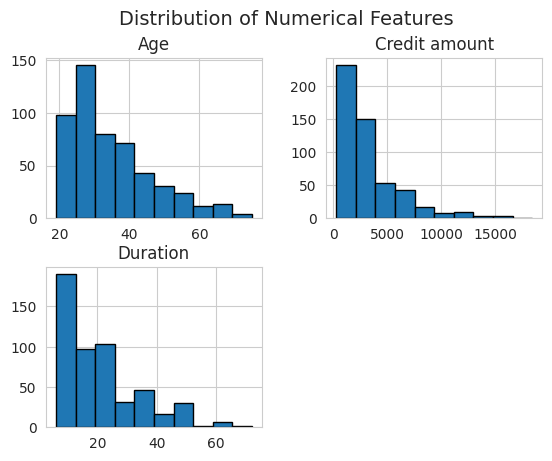

In [21]:
df[["Age","Credit amount", "Duration"]].hist(bins = 10, edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

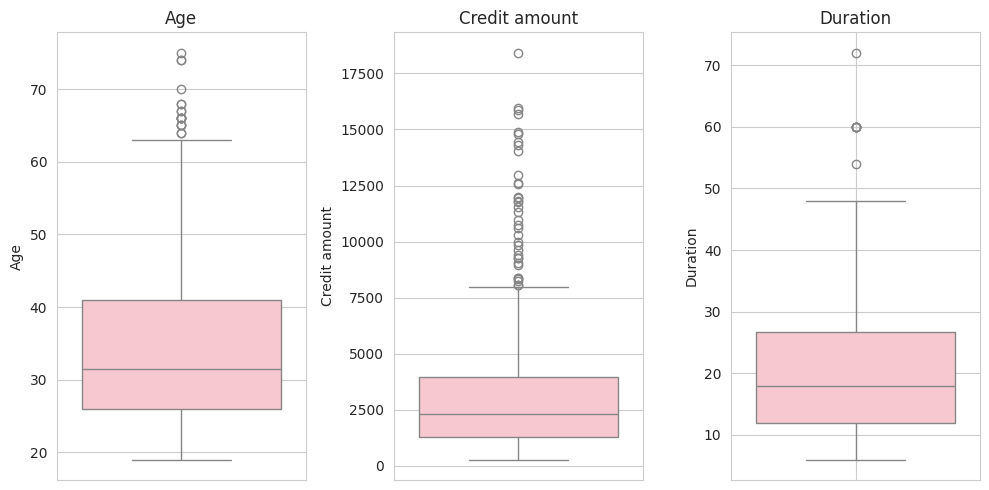

In [22]:
plt.figure(figsize= (10,5))
for i, col in enumerate (['Age', "Credit amount", "Duration"]):
  plt.subplot(1,3,i+1)
  sns.boxplot(y=df[col], color = "pink")
  plt.title(col)

plt.tight_layout()
plt.grid(True)
plt.show()

In [23]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [24]:
categorical_cols = ["Sex", "Job", "Housing","Saving accounts", "Checking account", "Purpose"]

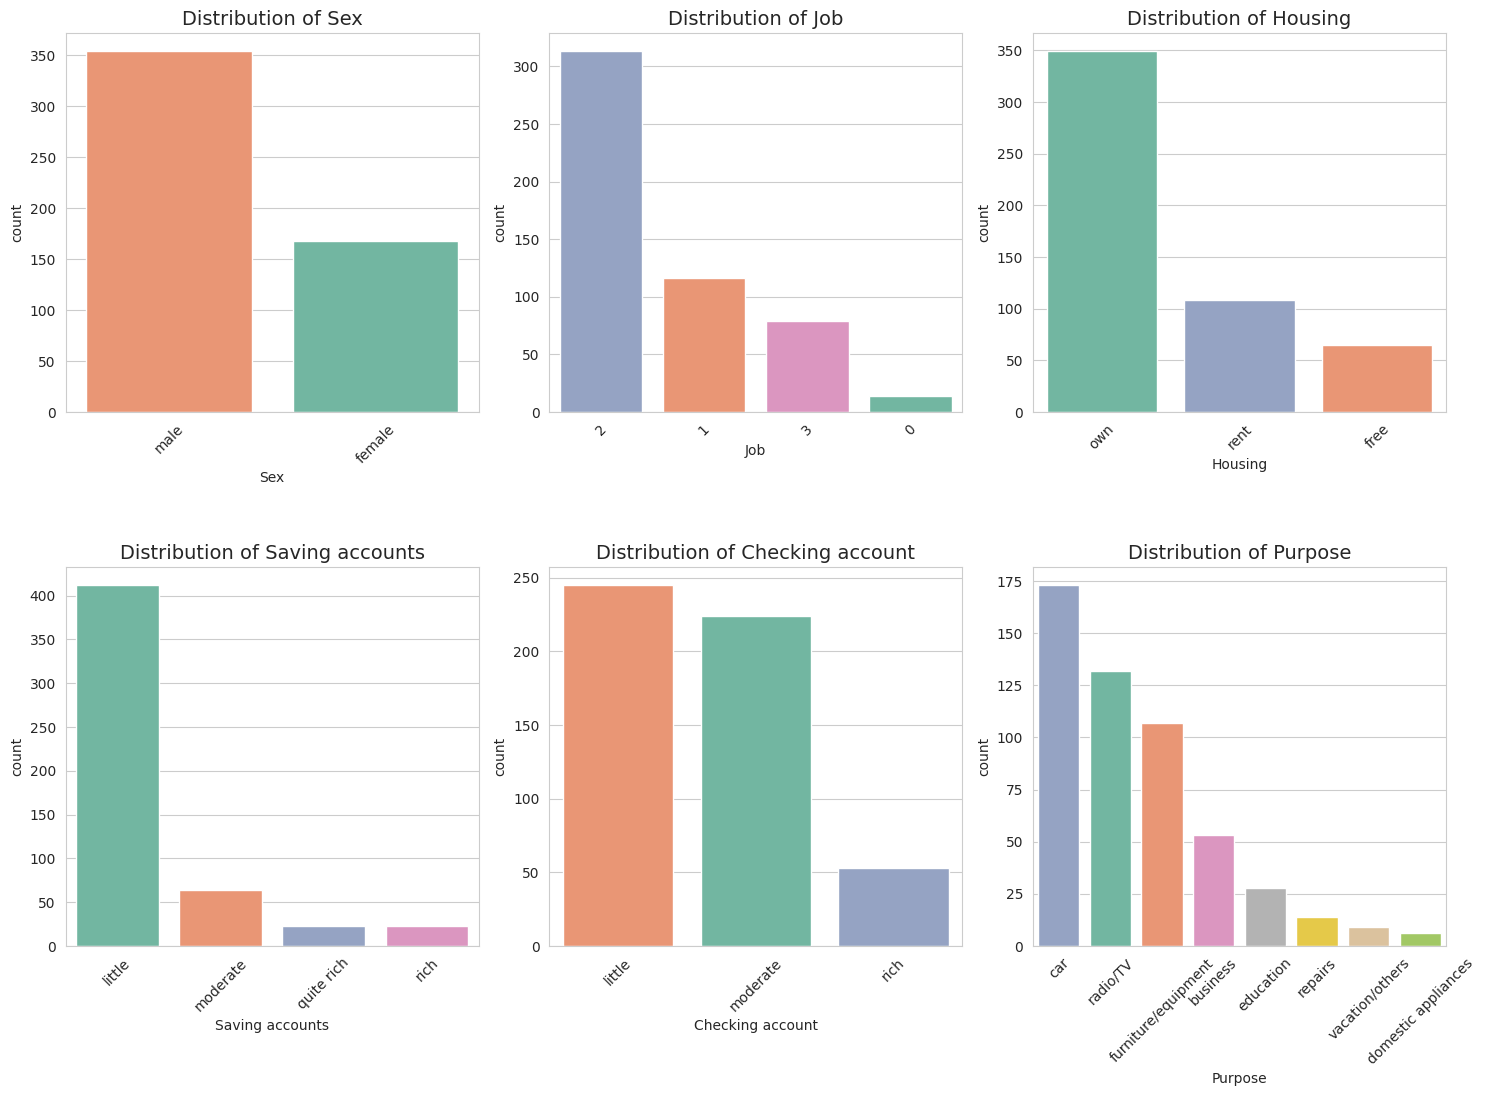

In [25]:
plt.figure(figsize=(15, 15))
for i, col in enumerate (categorical_cols):
  plt.subplot(3,3,i+1)
  sns.countplot(data=df, x=col, hue=col, palette ="Set2", order = df[col].value_counts().index, legend=False)
  plt.title(f"Distribution of {col}", fontsize=14)
  plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# order=df[col].value_counts().index: Sorts categories by frequency.
# Most common category appears first.

In [26]:
import math
n_cols = 3
n_rows = math.ceil(len(categorical_cols)/n_cols)

Countplots help analyze:

category imbalance
dominant classes
rare categories

Very important in:

EDA
preprocessing
classification problems

In [27]:
corr =  df[["Age", "Job", "Credit amount", "Duration"]].corr()

# how strongly 2 variables are related
# values range from : -1<= r <=1

In [28]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


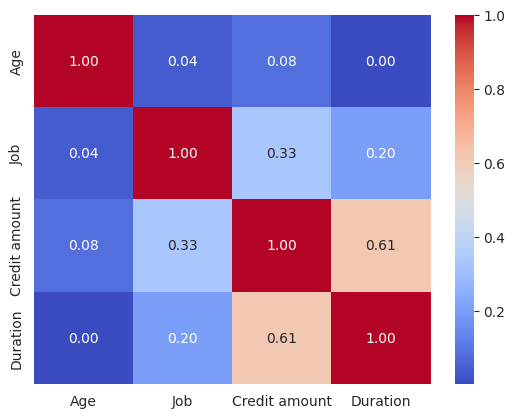

In [29]:
sns.heatmap(corr, annot=True, cmap ="coolwarm", fmt=".2f")
plt.show()

# strong positive - warm colors(red)
# strong negative - cool colors(blue)
# weak relation - neutral colors
# fmt - format number to 2 decimal places

In [30]:
df.groupby("Job")["Credit amount"].mean()

,Credit amount
Job,
0,1767.857143
1,2250.715517
2,3129.130990
3,5648.784810


In [31]:
df.groupby("Sex")["Credit amount"].mean()

,Credit amount
Sex,
female,2937.202381
male,3440.833333


In [32]:
pd.pivot_table(df, values= "Credit amount", index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


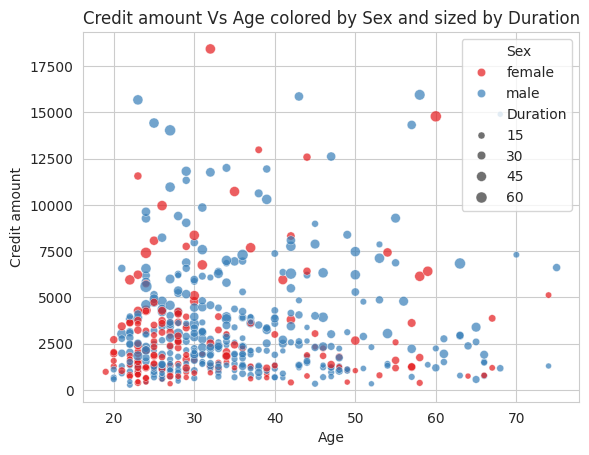

In [33]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size="Duration", alpha=0.7, palette="Set1")
plt.title("Credit amount Vs Age colored by Sex and sized by Duration")
plt.show()

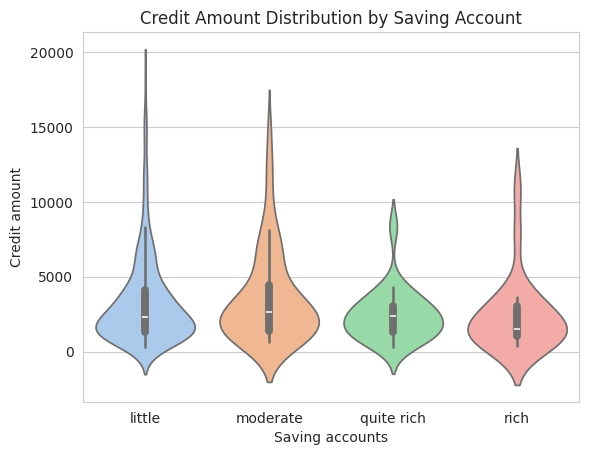

In [34]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="pastel", hue="Saving accounts", legend=False)
plt.title("Credit Amount Distribution by Saving Account")
plt.show()

In [35]:
df["Risk"].value_counts(normalize=True)*100

,proportion
Risk,
good,55.747126
bad,44.252874


/tmp/ipykernel_518/4124016046.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x = "Risk", y=col, palette="pastel")
/tmp/ipykernel_518/4124016046.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x = "Risk", y=col, palette="pastel")
/tmp/ipykernel_518/4124016046.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x = "Risk", y=col, palette="pastel")


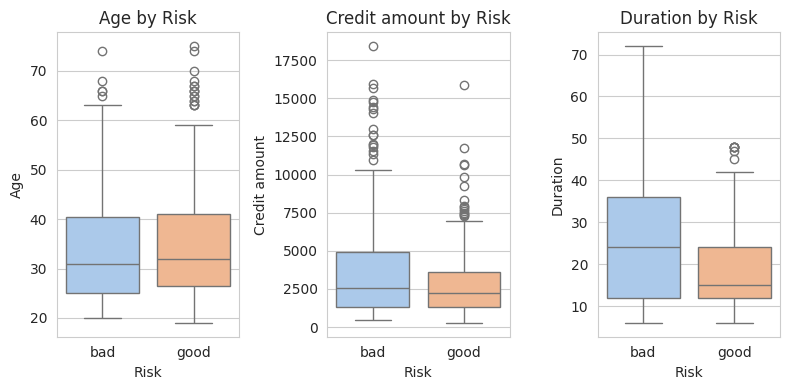

In [36]:
plt.figure(figsize=(8,4))
for i, col in enumerate(["Age","Credit amount", "Duration"]):
  plt.subplot(1,3,i+1)
  sns.boxplot(data=df, x = "Risk", y=col, palette="pastel")
  plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [37]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

In [38]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


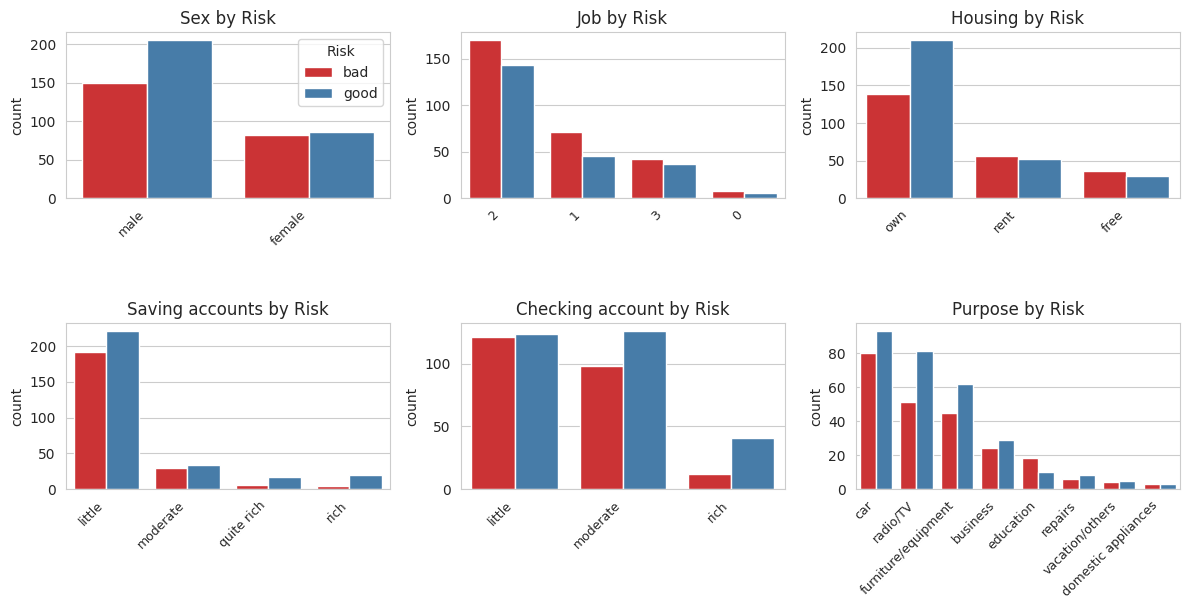

In [39]:
plt.figure(figsize=(12,8))
for i, col in enumerate(categorical_cols):
  plt.subplot(3,3,i+1)
  sns.countplot(data=df, x=col, hue="Risk", palette="Set1", order= df[col].value_counts().index, legend=(i==0))
  plt.title(f"{col} by Risk")
  plt.xticks(rotation=45, ha='right',fontsize=9)
  plt.xlabel("")

plt.tight_layout()
plt.show()

/tmp/ipykernel_518/2657450746.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(          # ← use ax.set_xticklabels instead of plt.xticks
/tmp/ipykernel_518/2657450746.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(          # ← use ax.set_xticklabels instead of plt.xticks
/tmp/ipykernel_518/2657450746.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(          # ← use ax.set_xticklabels instead of plt.xticks
/tmp/ipykernel_518/2657450746.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(          # ← use ax.set_xticklabels instead of plt.xticks
/tmp/ipykernel_518/2

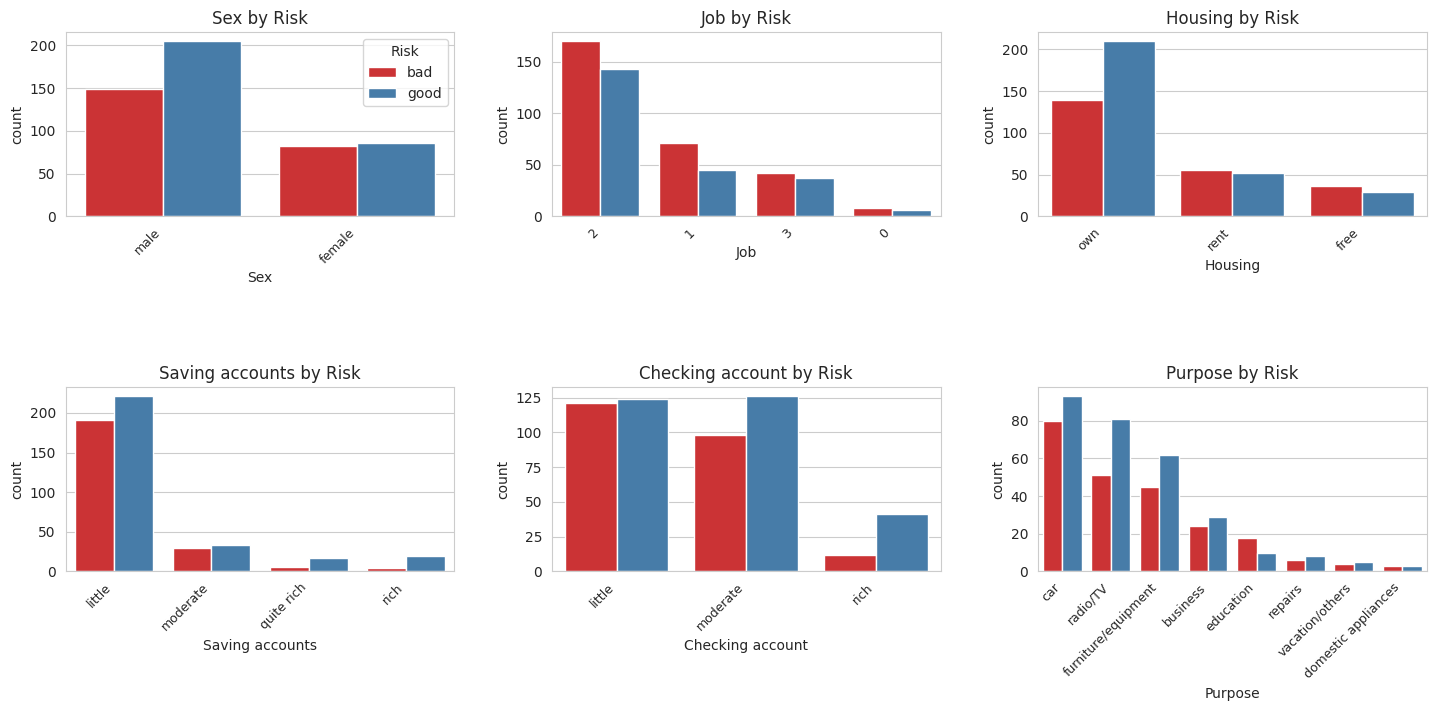

In [40]:
plt.figure(figsize=(15, 10))  # ← bigger canvas, gives labels room to breathe
for i, col in enumerate(categorical_cols):
    ax = plt.subplot(3, 3, i+1)  # ← capture the axes object as 'ax'
    sns.countplot(
        data=df, x=col, hue="Risk",
        palette="Set1",
        order=df[col].value_counts().index,
        legend=(i == 0)
    )
    plt.title(f"{col} by Risk")
    ax.set_xticklabels(          # ← use ax.set_xticklabels instead of plt.xticks
        ax.get_xticklabels(),    # get current labels first
        rotation=45,
        ha='right',              # anchor right edge to tick mark
        fontsize=9
    )

plt.tight_layout(pad=3.0)        # ← pad=3.0 adds breathing room between subplots
plt.show()

# **Feature Engineering**

In [41]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [42]:
features = ["Age","Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration"]
target = "Risk"

In [43]:
df_model = df[features + [target]].copy()

In [ ]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [44]:
from sklearn.preprocessing import LabelEncoder
import joblib

not doing any scaling operations, as on tree based model scaling is not used

In [45]:
cat_cols = df_model.select_dtypes(include = "object").columns.drop("Risk")

In [46]:
le_dict = {}

In [47]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [48]:
# for col in cat_cols:
#   le = LabelEncoder()
#   df_model[col] = le.fit_transform(df_model[col])
#   le_dict[col] = le
#   joblib.dump(le, f"{col}_enconder.pk1")

# Step 1 — Label encode the ordinal columns (order matters here)
ordinal_cols = ["Sex", "Saving accounts", "Checking account"]

le_dict = {}
for col in ordinal_cols:
    # Check if the column exists and is still of object type before encoding
    if col in df_model.columns and df_model[col].dtype == 'object':
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col])
        le_dict[col] = le
        joblib.dump(le, f"{col}_encoder.pkl")

# Step 2 — One Hot Encode Housing (no natural order)
# Check if 'Housing' column exists before trying to one-hot encode it
if "Housing" in df_model.columns:
    df_model = pd.get_dummies(df_model, columns=["Housing"], drop_first=True)

# What your df_model columns look like after both steps:
# Before:
# Age, Sex, Job, Housing, Saving accounts, Checking account, Credit amount, Duration, Risk

# After:
# Age, Sex, Job, Saving accounts, Checking account, Credit amount, Duration,
# Housing_own, Housing_rent,   ← Housing split into 2 binary columns
# Risk

In [49]:
# Start fresh from the clean subset
df_model = df[features + [target]].copy()

# Step 1 — One Hot Encode Housing FIRST (while it's still text)
df_model = pd.get_dummies(df_model,
                           columns=["Housing"],
                           drop_first=True,
                           dtype=int)

# Step 2 — Label Encode ordinal columns
ordinal_cols = ["Sex", "Saving accounts", "Checking account"]

le_dict = {}
for col in ordinal_cols:
    if col in df_model.columns and df_model[col].dtype == 'object':
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col])
        le_dict[col] = le
        joblib.dump(le, f"{col}_encoder.pkl")

# Step 3 — Encode target separately
df_model[target] = (df_model[target] == "good").astype(int)  # good=1, bad=0

# Verify
print(df_model.dtypes)
print()
print(df_model.head())

Age                 int64
Sex                 int64
Job                 int64
Saving accounts     int64
Checking account    int64
Credit amount       int64
Duration            int64
Risk                int64
Housing_own         int64
Housing_rent        int64
dtype: object

   Age  Sex  Job  Saving accounts  Checking account  Credit amount  Duration  \
0   22    0    2                0                 1           5951        48   
1   45    1    2                0                 0           7882        42   
2   53    1    2                0                 0           4870        24   
3   35    1    3                0                 1           6948        36   
4   28    1    3                0                 1           5234        30   

   Risk  Housing_own  Housing_rent  
0     0            1             0  
1     1            0             0  
2     0            0             0  
3     1            0             1  
4     0            1             0  


In [50]:
le_target = LabelEncoder()

In [51]:
target

'Risk'

In [52]:
df_model[target] = le_target.fit_transform(df_model[target])

In [53]:
df_model[target]

,Risk
0,0
1,1
2,0
3,1
4,0
...,...
517,1
518,1
519,1
520,0


In [54]:
df_model[target].value_counts()

,count
Risk,
1,291
0,231


In [55]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [56]:
df_model.head()

,Age,Sex,Job,Saving accounts,Checking account,Credit amount,Duration,Risk,Housing_own,Housing_rent
0,22,0,2,0,1,5951,48,0,1,0
1,45,1,2,0,0,7882,42,1,0,0
2,53,1,2,0,0,4870,24,0,0,0
3,35,1,3,0,1,6948,36,1,0,1
4,28,1,3,0,1,5234,30,0,1,0


In [57]:
from sklearn.model_selection import train_test_split

In [58]:
X = df_model.drop(target, axis=1)

In [59]:
y = df_model[target]

In [60]:
X

,Age,Sex,Job,Saving accounts,Checking account,Credit amount,Duration,Housing_own,Housing_rent
0,22,0,2,0,1,5951,48,1,0
1,45,1,2,0,0,7882,42,0,0
2,53,1,2,0,0,4870,24,0,0
3,35,1,3,0,1,6948,36,0,1
4,28,1,3,0,1,5234,30,1,0
...,...,...,...,...,...,...,...,...,...
517,48,1,1,0,1,1743,24,1,0
518,30,1,3,0,0,3959,36,1,0
519,40,1,3,0,0,3857,30,1,0
520,23,1,2,0,0,1845,45,0,0


In [61]:
y

,Risk
0,0
1,1
2,0
3,1
4,0
...,...
517,1
518,1
519,1
520,0


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

In [63]:
X_train.shape

(417, 9)

In [64]:
X_test.shape

(105, 9)

In [65]:
# train tune and elate the models

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve     # AUC-ROC is the gold standard for credit scoring

In [66]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
  grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
  grid.fit(X_train, y_train)

  best_model = grid.best_estimator_
  y_pred = best_model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  return best_model, acc, grid.best_params_

In [67]:
dt = DecisionTreeClassifier(random_state = 1, class_weight = "balanced")
dt_param_grid = {
    "max_depth" : [1,3,5,7,10],
    "min_samples_split": [2,5,9],
    "min_samples_leaf": [1,2,5]
}

In [68]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [69]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.638095238095238


In [70]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}


### Random Forest Classifier

Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees during training and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It generally reduces overfitting compared to a single decision tree.

In [71]:
rf = RandomForestClassifier(random_state=1, class_weight='balanced')
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [1, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [72]:
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.7047619047619048


In [73]:
print("best params", params_rf)

best params {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


### XGBoost Classifier

XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost provides a parallel tree boosting (also known as GBDT, GBM) that solves many data science problems in a fast and accurate way.

In [ ]:
# xgb = XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')
# xgb_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'subsample': [0.7, 0.9, 1.0]
# }

# best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:57:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# print("XGBoost Accuracy:", acc_xgb)

XGBoost Accuracy: 0.6761904761904762


In [74]:
et = ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [75]:
et_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

In [76]:
best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [77]:
print("Extra Trees Accuracy:", acc_et)

Extra Trees Accuracy: 0.6761904761904762


In [78]:
print("Best params", params_et)

Best params {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}


In [79]:
xgb = XGBClassifier(random_state =1, scale_pos_weight= (y_train == 0).sum()/ (y_train == 1).sum(), use_label_encoder=False, eval_metric='logloss')

In [80]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'sunsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

In [81]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:06:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "sunsample", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [82]:
print("XGB accuracy:", acc_xgb)

XGB accuracy: 0.7333333333333333


In [83]:
print("Best params", params_xgb)

Best params {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'sunsample': 0.7}


In [84]:
best_et.predict(X_test)

array([0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1])

In [85]:
# to export predictios to other app

joblib.dump(best_xgb, "xgb_credit_model.pkl")

['xgb_credit_model.pkl']

In [86]:
import joblib

model = joblib.load("xgb_credit_model.pkl")

print(model.get_booster().feature_names)

['Age', 'Sex', 'Job', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Housing_own', 'Housing_rent']
